In [1]:
# Summarize the Bank Account Fraud  dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn
from collections import Counter


In [2]:
df = pd.read_csv("Base.csv")
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [4]:
df['fraud_bool'].value_counts()
#the datset is imbalnced

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

In [5]:
# Count missing values for each column
missing_values_per_column = df.isna().sum()

print("Missing values per column:")
print(missing_values_per_column)

Missing values per column:
fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                 

In [6]:
numeric_features = df.select_dtypes(include='number').columns.tolist()
print(numeric_features)

['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


In [7]:
categoric_features=df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categoric_features)

['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


In [8]:
for x in categoric_features:
   print(df[x].unique())

['AA' 'AD' 'AB' 'AC' 'AE']
['CB' 'CA' 'CC' 'CF' 'CD' 'CE' 'CG']
['BC' 'BE' 'BD' 'BA' 'BB' 'BF' 'BG']
['INTERNET' 'TELEAPP']
['linux' 'other' 'windows' 'x11' 'macintosh']


In [9]:
X_orig = df.drop(["fraud_bool"],axis=1)
y_orig = df["fraud_bool"]

In [10]:
#drop the categorical feature for the time being ,only to showcasing how the imbance class can be syntecised.
X_orig = df.drop(["payment_type","employment_status","housing_status","source","device_os"],axis=1)


In [13]:
# As the dataset has large amount of data so slicing by 5000 rows.
X=X_orig.iloc[:5000]
y=y_orig.iloc[:5000]

In [15]:
X.shape,y.shape,y.value_counts()

((5000, 27),
 (5000,),
 fraud_bool
 0    4949
 1      51
 Name: count, dtype: int64)

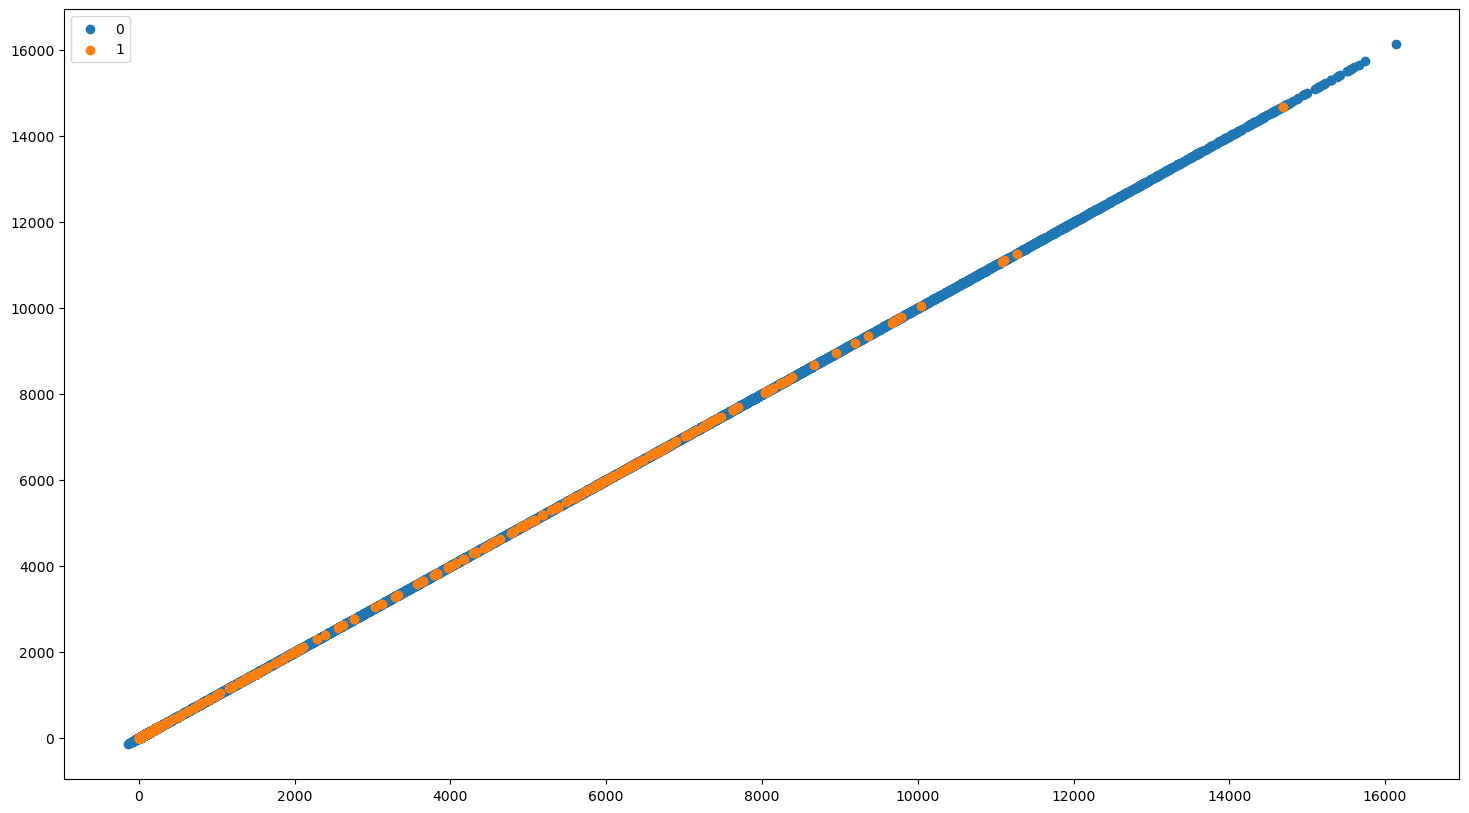

In [16]:
# scatter plot by class label
import matplotlib.pyplot as plt
plt.figure(figsize=(18,10))
import numpy as np
counter = Counter(y)
for label, _ in counter.items():
    row_ix = np.where(y == label)[0]
    plt.scatter(X.loc[row_ix], X.loc[row_ix], label=str(label))
plt.legend()
plt.savefig('Original.png')
plt.show()


# Under sampmpling-1-(Random)


In [17]:
from imblearn.under_sampling import RandomUnderSampler 
rs = RandomUnderSampler(random_state=42)

#print('Original dataset shape %s' % Counter(y))

X_res, y_res = rs.fit_resample(X, y)

print('After undersample dataset shape %s' % Counter(y_res))


After undersample dataset shape Counter({0: 51, 1: 51})


# Undersampling 2 - (Centriod)
Method that under samples the majority class by replacing a cluster of majority samples by the cluster centroid of a KMeans algorithm. This algorithm keeps N majority samples by fitting the KMeans algorithm with N cluster to the majority class and using the coordinates of the N cluster centroids as the new majority samples.


In [18]:
from imblearn.under_sampling import ClusterCentroids 
cc = ClusterCentroids(random_state=42)

print('Original dataset shape %s' % Counter(y))

X_res, y_res = cc.fit_resample(X, y)

print('After undersample dataset shape %s' % Counter(y_res))


Original dataset shape Counter({0: 4949, 1: 51})


/Users/gayatrimanjarisahu/miniconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


After undersample dataset shape Counter({0: 51, 1: 51})


# Undersampling 3 - (ENN)-EditedNearestNeighbours
This method cleans the dataset by removing samples close to the decision boundary. It removes observations from the majority class or classes when any or most of its closest neighours are from a different class.


In [19]:
from imblearn.under_sampling import EditedNearestNeighbours
ENN = EditedNearestNeighbours()

print('Original dataset shape %s' % Counter(y))

X_res, y_res = ENN.fit_resample(X, y)

print('After undersample dataset shape %s' % Counter(y_res))


Original dataset shape Counter({0: 4949, 1: 51})
After undersample dataset shape Counter({0: 4805, 1: 51})


# Oversampling 1 - Random
Object to over-sample the minority class(es) by picking samples at random with replacement. The bootstrap can be generated in a smoothed manner.


In [20]:
from imblearn.over_sampling import RandomOverSampler 
ROS = RandomOverSampler()

print('Original dataset shape %s' % Counter(y))

X_res, y_res = ROS.fit_resample(X, y)

print('After undersample dataset shape %s' % Counter(y_res))


Original dataset shape Counter({0: 4949, 1: 51})
After undersample dataset shape Counter({0: 4949, 1: 4949})


# Oversampling 2 - SMOTE
This object is an implementation of SMOTE - Synthetic Minority Over-sampling Technique as presented below.



In [21]:
from imblearn.over_sampling import SMOTE 
SMOTE = SMOTE()

print('Original dataset shape %s' % Counter(y))

X_res, y_res = SMOTE.fit_resample(X, y)

print('After undersample dataset shape %s' % Counter(y_res))



Original dataset shape Counter({0: 4949, 1: 51})
After undersample dataset shape Counter({0: 4949, 1: 4949})


# Mix of undersample and oversample - SMOTEENN
Over-sampling using SMOTE and cleaning using ENN.
Combine over- and under-sampling using SMOTE and Edited Nearest Neighbours.


Original dataset shape Counter({0: 4949, 1: 51})
After undersample dataset shape Counter({1: 4908, 0: 4313})


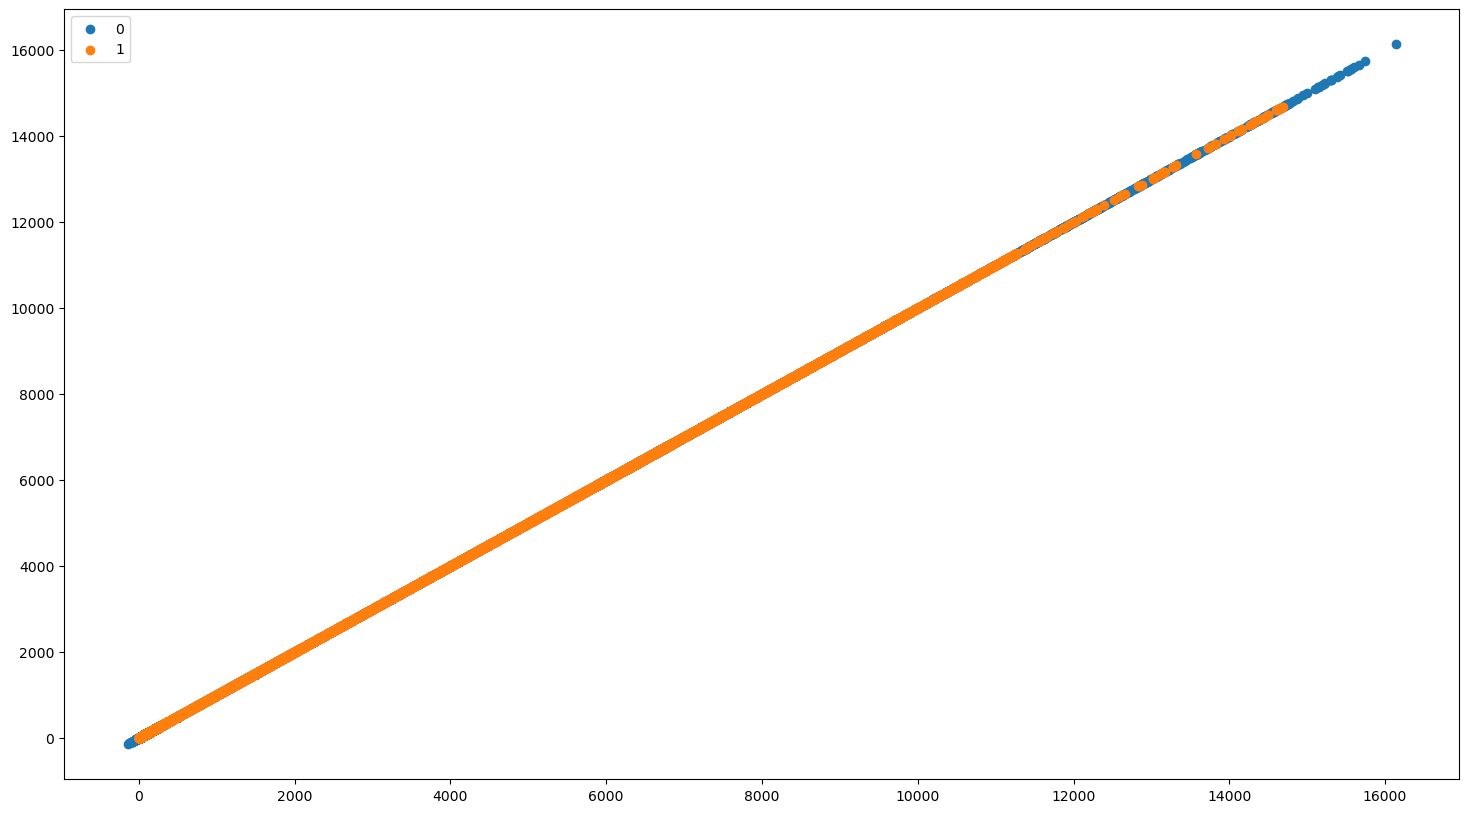

In [24]:
from imblearn.combine import SMOTEENN 
SMOTEENN = SMOTEENN()

print('Original dataset shape %s' % Counter(y))

X_res, y_res = SMOTEENN.fit_resample(X, y)

print('After undersample dataset shape %s' % Counter(y_res))
# scatter plot by class label
import matplotlib.pyplot as plt
plt.figure(figsize=(18,10))
import numpy as np
counter = Counter(y_res)
for label, _ in counter.items():
    row_ix = np.where(y_res == label)[0]
    plt.scatter(X_res.loc[row_ix], X_res.loc[row_ix], label=str(label))
plt.legend()
plt.show()


# Ensemble Method 1 - EasyEnsembleClassifier
Bag of balanced boosted learners also known as EasyEnsemble.
This algorithm is known as EasyEnsemble [1]. The classifier is an ensemble of AdaBoost learners trained on different balanced bootstrap samples. The balancing is achieved by random under-sampling.


In [23]:
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
print('Original dataset shape %s' % Counter(y))

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=0)
eec = EasyEnsembleClassifier(random_state=42)
eec.fit(X_train, y_train) 
y_pred = eec.predict(X_test)
print(confusion_matrix(y_test, y_pred))

Original dataset shape Counter({0: 4949, 1: 51})
[[1235    0]
 [   0   15]]


# BalancedRandomForestClassifier
A balanced random forest classifier.

A balanced random forest differs from a classical random forest by the fact that it will draw a bootstrap sample from the minority class and sample with replacement the same number of samples from the majority class.

In [26]:
from imblearn.ensemble import BalancedRandomForestClassifier
print('Original dataset shape %s' % Counter(y))

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=0)
brc = BalancedRandomForestClassifier(
                                    sampling_strategy="all", replacement=True, max_depth=2, random_state=42,bootstrap=False)
brc.fit(X_train, y_train) 
y_pred = brc.predict(X_test)
print(confusion_matrix(y_test, y_pred))

Original dataset shape Counter({0: 4949, 1: 51})
[[1235    0]
 [   0   15]]


# BalancedBaggingClassifier
A Bagging classifier with additional balancing.

This implementation of Bagging is similar to the scikit-learn implementation. It includes an additional step to balance the training set at fit time using a given sampler.

This classifier can serves as a basis to implement various methods such as Exactly Balanced Bagging , Roughly Balanced Bagging , Over-Bagging , or SMOTE-Bagging .



In [27]:
from imblearn.ensemble import BalancedBaggingClassifier

print('Original dataset shape %s' % Counter(y))
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=0)
bbc = BalancedBaggingClassifier(random_state=42)
bbc.fit(X_train, y_train)
y_pred = bbc.predict(X_test)
print(confusion_matrix(y_test, y_pred))


Original dataset shape Counter({0: 4949, 1: 51})
[[1235    0]
 [   0   15]]
